In [2]:
import os

# Subir un nivel respecto a la carpeta actual
os.chdir("..")

import numpy as np
from globals import SAMPLE_RATE
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from Utils import from_matrix_to_preset, denormalize_preset, pretty_print, get_audio, split_audio
import numpy as np
import matplotlib.pyplot as plt
from Optimizers import search_with_DE, search_with_CMA, evaluate_target, render_presets

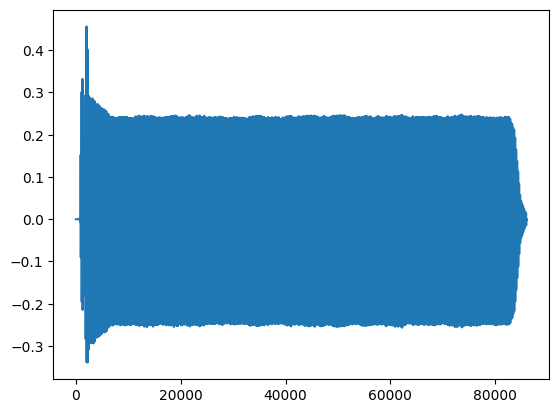

In [3]:
audio_path = 'C:/Users/bryan/Documents/GitHub/Synth/exports/Trumpet_target.wav'
audio = get_audio(audio_path)

plt.plot(audio)
plt.show()
Audio(audio, rate=SAMPLE_RATE)

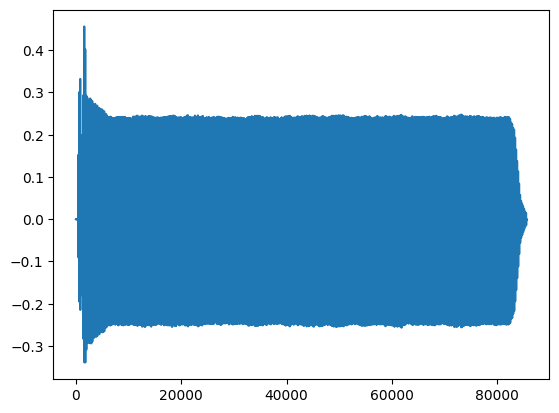

Pieces 1


In [4]:
audio_segments = split_audio(audio, prominence=0.06)

audio_segments = audio_segments[0:2]

for audio_segment in audio_segments:
    plt.plot(audio_segment)
    plt.show()
    display(Audio(audio_segment, rate=SAMPLE_RATE))

print('Pieces', len(audio_segments))

Piece 1


c:\Users\bryan\Documents\GitHub\Synth\venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:487: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


differential_evolution step 1: f(x)= 0.15424239398615172
differential_evolution step 2: f(x)= 0.15424239398615172
differential_evolution step 3: f(x)= 0.14377553725535158
differential_evolution step 4: f(x)= 0.14377553725535158
differential_evolution step 5: f(x)= 0.14377553725535158
differential_evolution step 6: f(x)= 0.14377553725535158
differential_evolution step 7: f(x)= 0.14377553725535158
differential_evolution step 8: f(x)= 0.14377553725535158
differential_evolution step 9: f(x)= 0.14377553725535158
differential_evolution step 10: f(x)= 0.14377553725535158
differential_evolution step 11: f(x)= 0.14377553725535158
differential_evolution step 12: f(x)= 0.14377553725535158
differential_evolution step 13: f(x)= 0.14377553725535158
differential_evolution step 14: f(x)= 0.14377553725535158
differential_evolution step 15: f(x)= 0.14377553725535158
differential_evolution step 16: f(x)= 0.14377553725535158
differential_evolution step 17: f(x)= 0.14261382891780255
differential_evolution 

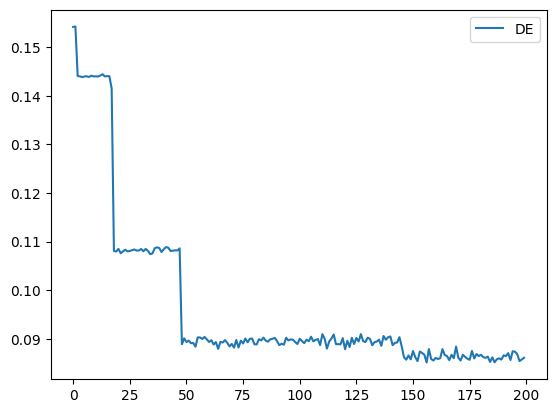

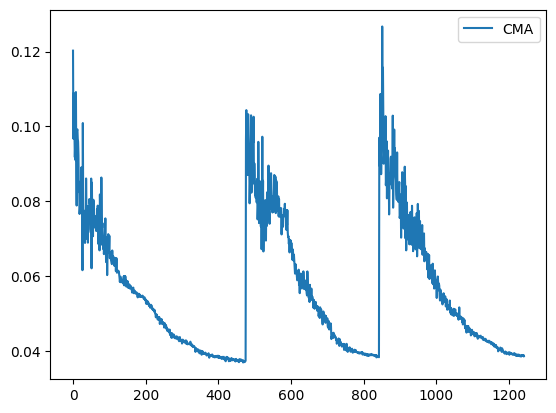

In [5]:
estimated_presets = []
i = 1
last_best = None

if __name__ == '__main__':
    for audio_segment in audio_segments:
        print('Piece', i)
        target_C = evaluate_target(np.expand_dims(audio_segment, axis=0))
        duration = len(audio_segment) / SAMPLE_RATE
        if last_best is None:
            best, episodes_de = search_with_DE(target_C, duration, disp=True, maxiter=200)
            best, episodes_cma = search_with_CMA(target_C, duration, best)
            print(episodes_de, episodes_cma)
        else:
            best, _ = search_with_CMA(target_C, duration, last_best)

        last_best = best
        estimated_presets.append((best, duration))
        i+=1

        plt.plot(episodes_de, label='DE')
        plt.legend()
        plt.show()
        plt.plot(episodes_cma, label='CMA')
        plt.legend()
        plt.show()

In [6]:
predicted_joined_audio = []

for preset, duration in estimated_presets:
    preset = np.expand_dims(preset, axis=0)
    # error = evaluate_presets((denormalize_preset(from_matrix_to_preset(preset)), target_C, duration))
    # print('Error', error)
    # target_audio = np.expand_dims(audio_segments[0], axis=0)
    predicted_audio = render_presets(denormalize_preset(from_matrix_to_preset(preset)), duration)
    predicted_joined_audio.append(predicted_audio[0])

    denormalized_predicted_preset = denormalize_preset(from_matrix_to_preset(preset))
    pretty_print(denormalized_predicted_preset)

predicted_joined_audio = np.concatenate(predicted_joined_audio, axis=0)

print(min(episodes_cma))

{
  osc1_shape:   [
    3.1322873834832965
  ]
  osc1_phase:   [
    0.25940124476505255
  ]
  osc1_volume:   [
    0.0018934072236414833
  ]
  osc1_freq:   [
    660.6779583116887
  ]
  osc2_shape:   [
    1.9464806082024373
  ]
  osc2_phase:   [
    0.6677000697970668
  ]
  osc2_volume:   [
    0.19111235966907536
  ]
  osc2_freq:   [
    233.3329785610253
  ]
  osc3_shape:   [
    2.2008443754046967
  ]
  osc3_phase:   [
    0.5688739818009229
  ]
  osc3_volume:   [
    0.00036141752522265167
  ]
  osc3_freq:   [
    15530.307765737765
  ]
  osc4_shape:   [
    0.3174656478674064
  ]
  osc4_phase:   [
    0.9279774447410128
  ]
  osc4_volume:   [
    1.7906812847003127e-05
  ]
  osc4_freq:   [
    24.577284957522767
  ]
  oscnoise_volume:   [
    0.011893014211929898
  ]
  filter_envelope_attack:   [
    0.1886870916987437
  ]
  filter_envelope_decay:   [
    0.2010397633447722
  ]
  filter_envelope_sustain:   [
    0.3632459319282069
  ]
  filter_envelope_release:   [
    0.1113004

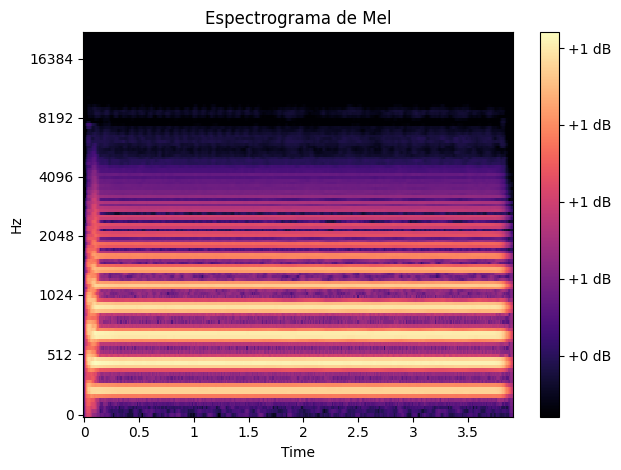

In [7]:
spect = evaluate_target(np.array([audio[:120000]]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(audio[:120000], rate=SAMPLE_RATE))

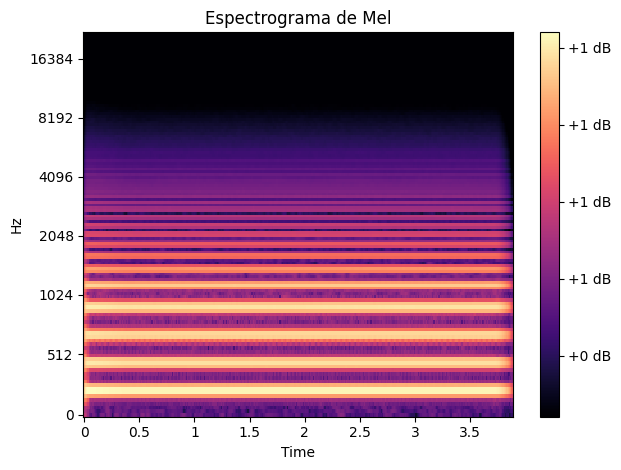

In [8]:
spect = evaluate_target(np.array([predicted_joined_audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(predicted_joined_audio, rate=SAMPLE_RATE))